<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-CD0198EN-SkillsNetwork/labs/images/IBM_logo.png" width="300" alt="cognitiveclass.ai logo">
</center>

# Python Exercise for Introductory Data Analysis

Estimated time needed: 60 minutes


This lab is designed to allow for running basic Python commands for Introductory Data Analysis. It covers some sample data uploads, pre-processing, analyzing and visualization. Python provides a very rich environment to conduct deeper analyses and build sophisticated statistical models. For learning such advanced techniques, the student is encouraged to register for ML and Datascience courses available through IBM's certification courses


## __Table of Contents__

<ol>
    <li><a href="#Objectives">Objectives</a></li>
    <li><a href="#Setup">Setup</a></li>
    <li><a href="#Data">Data</a></li>  
    <li><a href="#Exercises">Exercises</a></li>
</ol>


## Objectives

After completing this lab you will be able to:

Use Python to solve load data, pre-process it, analyze and visualize it.


## Setup

Operations in Python require certain libraries to be loaded, depending on the function that one is trying to use. There are several libraries available for use. Some Python enviroments come with pre-loaded libraries. However, in this exercise, we will see how to load such libraries


## Data 

###US Housing Market Factors

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-CD0198EN-SkillsNetwork/labs/images/housing-cover.jpg" width="30%" alt="housing image">

US housing market depends on various factors. Here are some macroeconomic factors relevant to the market. The following attributes have been collected,

 - `Date`: Year 

 - `House_Price_Index`: House price change according to the index base period set (you can check the date at which this value is 100). 

 - `Stock_Price_Index`: Stock price change according to the index base period set (you can check the date at which this value is 100). 

 - `Consumer_Price_Index`: The Consumer Price Index measures the overall change in consumer prices based on a representative basket of goods and services over time. 

 - `Population`: Population of USA (unit: thousands). 

 - `Unemployment_Rate`: Unemployment rate of USA (unit: percentage). 

 - `Real_GDP`: GDP with adjusted inflation (Annual version unit: billions of chain 2012 dollars in, Monthly version unit: Annualised change). 

 - `Mortgage_Rate`: Interest charged on mortgages (unit: percentage). 

 - `Real_Disposable_Income` (Real Disposable Personal Income): Money left from salary after all the taxes are paid (unit: billions of chain 2012 dollars). 
 
Your task is to load the data, pre-process it, explore and visualize it


# Install Libraries


In [1]:
#you are running the lab in your  browser, so we will install the libraries using ``piplite``
import piplite
import micropip
await piplite.install(['pandas'])
await piplite.install(['matplotlib'])
await piplite.install(['scipy'])
await piplite.install(['seaborn'])
await micropip.install(['ipywidgets'],keep_going=True)
await micropip.install(['tqdm'],keep_going=True)

# Exercises


### Exercise 1: Import numpy, pandas and matplotlib libraries into Jupyter 


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<ipython-input-4-b478a6fd18e5>:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


<details>
    <summary>Click here for Solution</summary>

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
```

</details>


### Exercise 2: Create a dataframe from a csv file and display the size of the dataframe 


In [5]:
#This function will download the dataset into your browser 

from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

In [6]:
path = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-CD0198EN-SkillsNetwork/labs/data/Annual_Macroeconomic_Factors.csv'
await download(path, "Annual_Macroeconomic_Factors.csv")
path="Annual_Macroeconomic_Factors.csv"

In [7]:
df =pd.read_csv("Annual_Macroeconomic_Factors.csv")
df.size
df.head()

,Date,House_Price_Index,Stock_Price_Index,Consumer_Price_Index,Population,Unemployment_Rate,Real_GDP,Mortgage_Rate,Real_Disposable_Income
0,1975-01-01,61.0900,67.14653,65.30488,0.98599,8.46667,5648.462,9.04712,19908
1,1976-01-01,65.5250,79.96264,69.05653,0.95022,7.71667,5952.809,8.86585,20346
2,1977-01-01,73.4350,78.82540,73.54636,1.00577,7.06667,6228.076,8.84519,20780
3,1978-01-01,83.7450,78.84679,79.15866,1.05957,6.06667,6572.819,9.64173,21497
4,1979-01-01,95.1325,85.63207,88.06755,1.10358,5.83333,6780.924,11.20365,21672


<details>
    <summary>Click here for Solution</summary>

```python
data = pd.read_csv('Annual_Macroeconomic_Factors.csv')
data.size
```

</details>


### Exercise 3: Create a reduced dataframe by dropping Stock_Price_Index


In [8]:
reduce=df.drop(['Stock_Price_Index'],axis=1)
reduce.head()

,Date,House_Price_Index,Consumer_Price_Index,Population,Unemployment_Rate,Real_GDP,Mortgage_Rate,Real_Disposable_Income
0,1975-01-01,61.0900,65.30488,0.98599,8.46667,5648.462,9.04712,19908
1,1976-01-01,65.5250,69.05653,0.95022,7.71667,5952.809,8.86585,20346
2,1977-01-01,73.4350,73.54636,1.00577,7.06667,6228.076,8.84519,20780
3,1978-01-01,83.7450,79.15866,1.05957,6.06667,6572.819,9.64173,21497
4,1979-01-01,95.1325,88.06755,1.10358,5.83333,6780.924,11.20365,21672


<details>
    <summary>Click here for Solution</summary>

```python
#dropping a column (axis=1); dropping a row (axis=0)
data_reduced = data.drop(["Stock_Price_Index"], axis=1)
data_reduced.head()
```

</details>


### Exercise 4: Create a smaller dataframe by dropping data that has Unemployment_Rate > 9.5% 


In [9]:
rate=reduce.drop(reduce[reduce['Unemployment_Rate']>9.5].index)
rate.head(2)

,Date,House_Price_Index,Consumer_Price_Index,Population,Unemployment_Rate,Real_GDP,Mortgage_Rate,Real_Disposable_Income
0,1975-01-01,61.090,65.30488,0.98599,8.46667,5648.462,9.04712,19908
1,1976-01-01,65.525,69.05653,0.95022,7.71667,5952.809,8.86585,20346


<details>
    <summary>Click here for Solution</summary>

```python
#dropping rows (axis=0) that satisfy a criterion
data_reduced_subset = data.drop(data[data["Unemployment_Rate"] > 9.5].index)
data_reduced_subset.head()
```

</details>


### Exercise 5: Get the dimensions of the dataframe created in Question 4 


In [10]:
rate.size

352

In [11]:
rate.head(1)

,Date,House_Price_Index,Consumer_Price_Index,Population,Unemployment_Rate,Real_GDP,Mortgage_Rate,Real_Disposable_Income
0,1975-01-01,61.09,65.30488,0.98599,8.46667,5648.462,9.04712,19908


<details>
    <summary>Click here for Solution</summary>

```python
##size is the number of elements in the dataframe (number of rows * number of columns)
data_reduced_subset.size
```

</details>


### Exercise 6: Create a dataframe by selecting Real_Disposable_Income and House_Price_Index attributes from the original dataset and print out the statistics for these attributes 


In [16]:
income=rate[['Real_Disposable_Income','House_Price_Index']]
income.describe()


,Real_Disposable_Income,House_Price_Index
count,44.000000,44.000000
mean,32335.727273,244.023182
std,7955.050162,120.687411
min,19908.000000,61.090000
25%,26318.500000,151.041250
50%,32060.500000,216.666250
75%,38333.250000,342.091875
max,48219.000000,523.260000


<details>
    <summary>Click here for Solution</summary>

```python
disp_income=data[['Real_Disposable_Income', 'House_Price_Index']]
disp_income.describe()
```

</details>


### Exercise 7: Plot a scatter plot between House_Price_Index and Real_Disposable_Income 


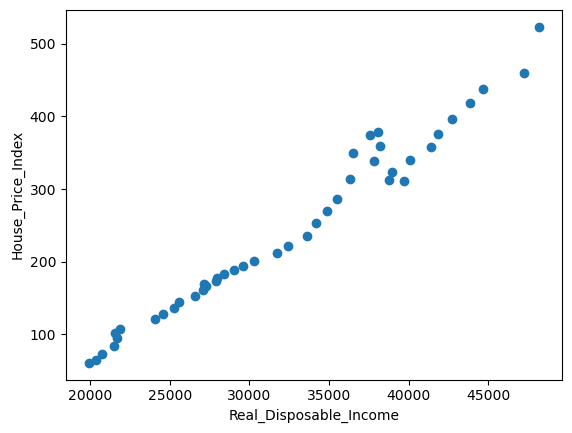

In [17]:
x=income['Real_Disposable_Income']
y=income['House_Price_Index']
plt.scatter(x,y)
plt.xlabel("Real_Disposable_Income")
plt.ylabel("House_Price_Index")
plt.show()

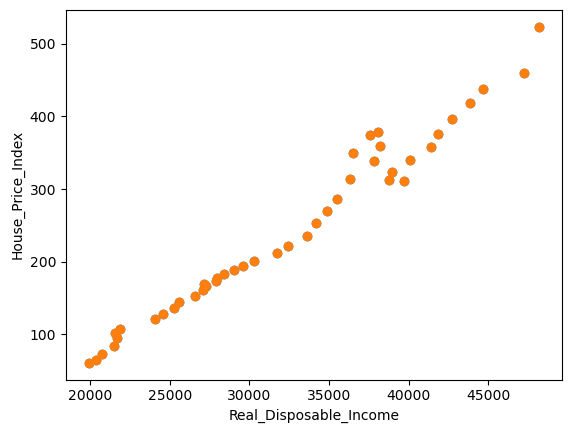

In [18]:
x=income['Real_Disposable_Income']
y=income['House_Price_Index']
plt.scatter(x,y)
plt.scatter(x,y)
plt.xlabel("Real_Disposable_Income")
plt.ylabel("House_Price_Index")
plt.show()

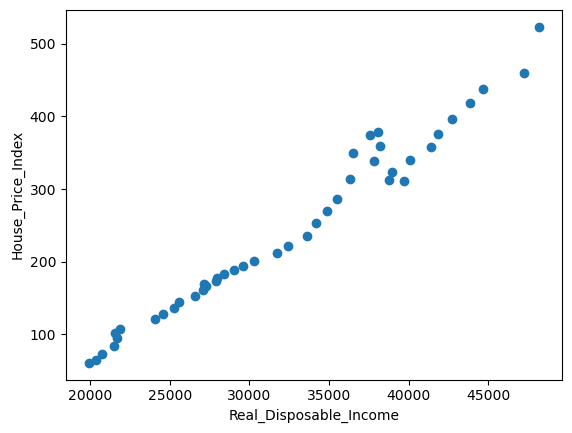

In [21]:
x=rate['Real_Disposable_Income']
y=rate['House_Price_Index']
plt.scatter(x,y)
plt.xlabel("Real_Disposable_Income")
plt.ylabel("House_Price_Index")
plt.show()

<details>
    <summary>Click here for Solution</summary>

```python
x=data['Real_Disposable_Income']
y=data['House_Price_Index']
plt.scatter(x,y)
plt.xlabel("Real_Disposable_Income")
plt.ylabel("House_Price_Index")
plt.show()
```

</details>


### Exercise 8: Create a bar chart with date (as year) on X-axis and Real_GDP on the Y-axis 


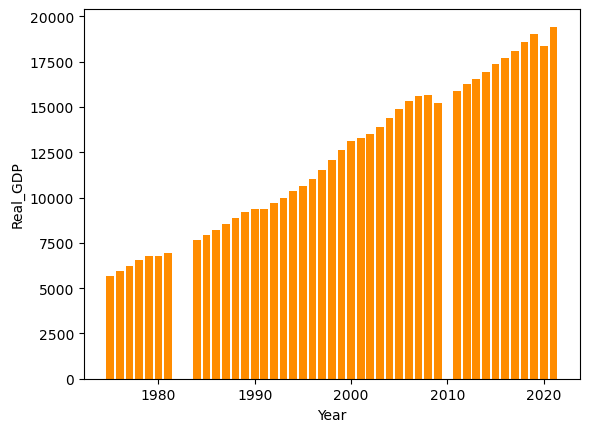

In [28]:
#x=rate['Date']
x=pd.DatetimeIndex(rate['Date']).year
y=rate['Real_GDP']
plt.bar(x,y,color='darkorange')
plt.xlabel('Year')
plt.ylabel('Real_GDP')
plt.show()



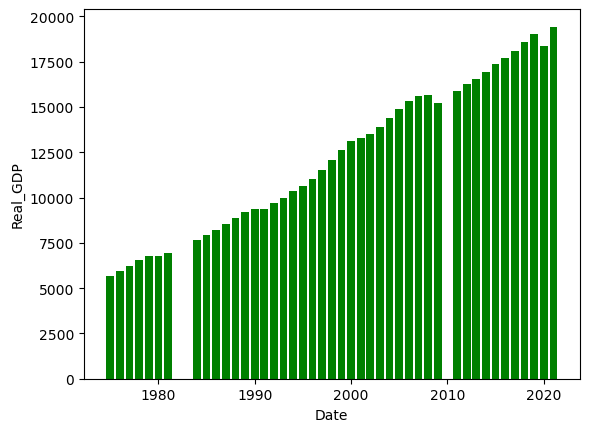

In [23]:
x=pd.DatetimeIndex(rate['Date']).year
y=rate['Real_GDP']
plt.bar(x,y,color ='green')
plt.xlabel("Date")
plt.ylabel("Real_GDP")
plt.show()

<details>
    <summary>Click here for Solution</summary>

```python
x=pd.DatetimeIndex(data['Date']).year
y=data['Real_GDP']
plt.bar(x,y,color ='green')
plt.xlabel("Date")
plt.ylabel("Real_GDP")
plt.show()
```

</details>


### Exercise 9: Create a combo chart with date on X-axis and Consumer_Price_Index on Y1-axis (bar) and Mortgage_Rate (line) on Y2-axis 


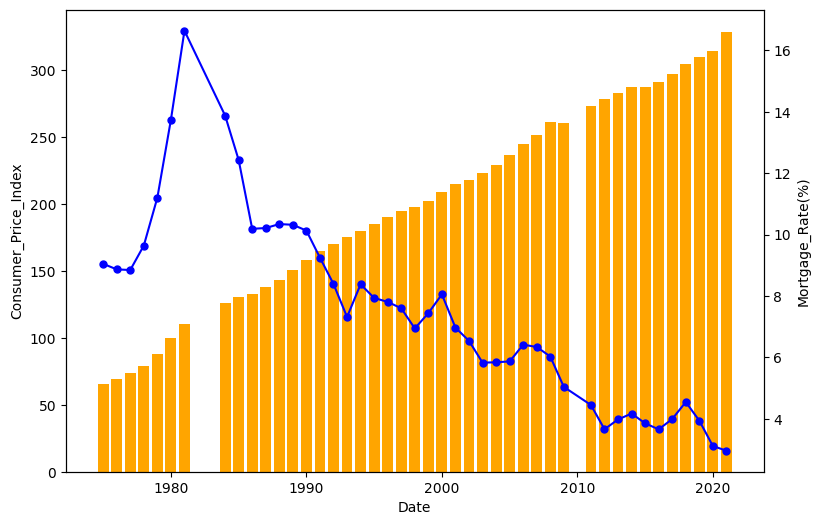

In [29]:
fig, ax1 = plt.subplots(figsize=(9, 6))
x=pd.DatetimeIndex(rate['Date']).year
y1=rate['Consumer_Price_Index']
y2=rate['Mortgage_Rate']

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()  
ax1.bar(x,y1, color="orange")
ax2.plot(x,y2, color="blue", marker=".", markersize=10)
ax1.set_xlabel("Date")
ax1.set_ylabel("Consumer_Price_Index")
ax2.set_ylabel("Mortgage_Rate(%)")
plt.show()

<details>
    <summary>Click here for Solution</summary>

```python
fig, ax1 = plt.subplots(figsize=(9, 6))
x=pd.DatetimeIndex(data['Date']).year
y1=data['Consumer_Price_Index']
y2=data['Mortgage_Rate']

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()  
ax1.bar(x,y1, color="orange")
ax2.plot(x,y2, color="blue", marker=".", markersize=10)
ax1.set_xlabel("Date")
ax1.set_ylabel("Consumer_Price_Index")
ax2.set_ylabel("Mortgage_Rate(%)")
plt.show()
```

</details>


### Exercise 10: Create sub-plots with Date on X-axis and Stock_Price_Index on subplot 1 and Consumer_Price_Index on subplot 2


In [31]:
rate.head()

,Date,House_Price_Index,Consumer_Price_Index,Population,Unemployment_Rate,Real_GDP,Mortgage_Rate,Real_Disposable_Income
0,1975-01-01,61.0900,65.30488,0.98599,8.46667,5648.462,9.04712,19908
1,1976-01-01,65.5250,69.05653,0.95022,7.71667,5952.809,8.86585,20346
2,1977-01-01,73.4350,73.54636,1.00577,7.06667,6228.076,8.84519,20780
3,1978-01-01,83.7450,79.15866,1.05957,6.06667,6572.819,9.64173,21497
4,1979-01-01,95.1325,88.06755,1.10358,5.83333,6780.924,11.20365,21672


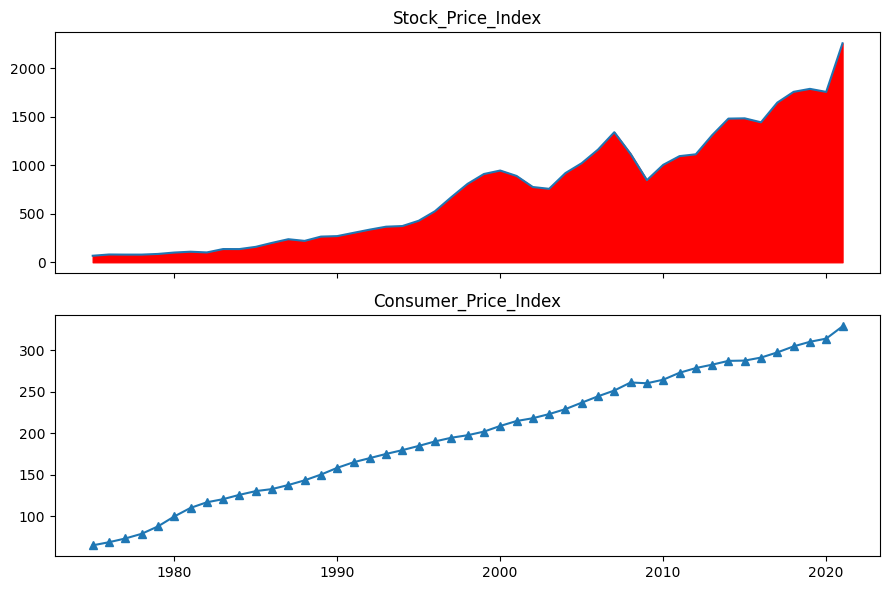

In [35]:
x0=pd.DatetimeIndex(df['Date']).year
x1=df['Stock_Price_Index']
x2=df['Consumer_Price_Index']

plt.subplots(2, 1, sharex=True, figsize=(9, 6))

plt.subplot(2,1,1)
plt.plot(x0,x1)
plt.fill_between(x0,x1,color="red")
plt.title("Stock_Price_Index")
plt.subplot(2,1,2)
plt.plot(x0,x2,marker="^")
plt.title("Consumer_Price_Index")

plt.tight_layout()
plt.show()


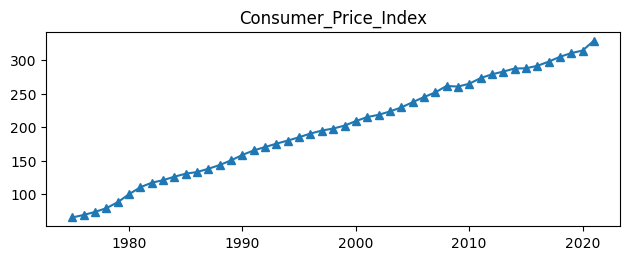

In [34]:
plt.subplot(2,1,2)
plt.plot(x0,x2,marker="^")
plt.title("Consumer_Price_Index")

plt.tight_layout()
plt.show()

<details>
    <summary>Click here for Solution</summary>

```python
x0=pd.DatetimeIndex(data['Date']).year
x1=data['Stock_Price_Index']
x2=data['Consumer_Price_Index']

plt.subplots(2, 1, sharex=True, figsize=(9, 6))

plt.subplot(2,1,1)
plt.plot(x0,x1)
plt.fill_between(x0,x1,color="red")
plt.title("Stock_Price_Index")

plt.subplot(2,1,2)
plt.plot(x0,x2,marker="^")
plt.title("Consumer_Price_Index")

plt.tight_layout()
plt.show()
```

</details>


## Change Log

| Date (YYYY-MM-DD) | Version | Changed By | Change Description                                         |
| ----------------- | ------- | ---------- | ---------------------------------------------------------- |
| 2022-01-24        | 1.2     | Lakshmi     | Added logo and piplite updates |


## <h3 align="center"> © IBM Corporation 2023. All rights reserved. <h3/>
